# EXPERIMENT NO. 2 — Comparative Study of Activation Functions and Optimization Algorithms in Deep Learning

**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  


## TASK A — Visualization of Activation Functions
Compare Sigmoid, Tanh and ReLU using output range, saturation, gradient behavior and computational simplicity.

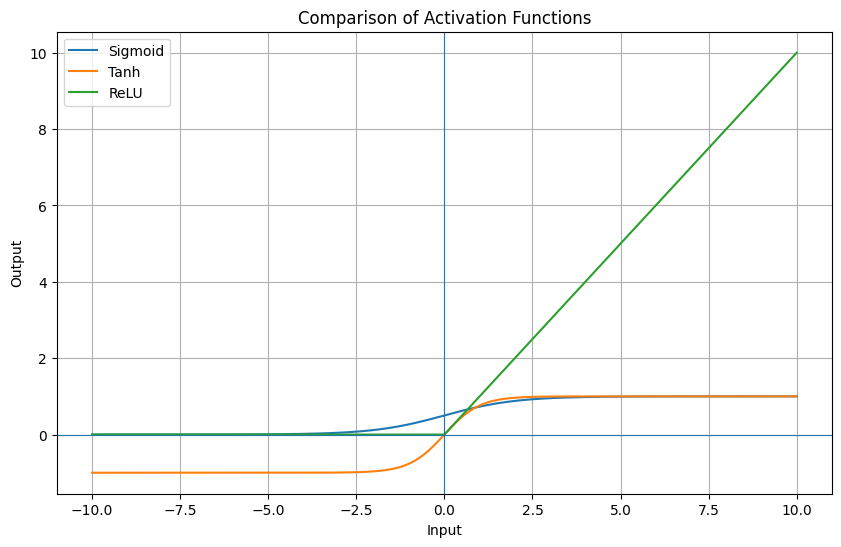

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Comparison of Activation Functions')
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.legend()
plt.grid()
plt.show()

### Task A Observation
- Sigmoid: output range 0 to 1; saturates at large positive and negative inputs.
- Tanh: output range -1 to 1; zero-centered but also has saturation regions.
- ReLU: output range 0 to infinity; simple and computationally efficient.
- Sigmoid and Tanh may suffer from vanishing gradients in saturation regions.
- ReLU generally provides better gradient flow for positive inputs.

## TASK B — Performance Comparison of Activation Functions
The same ANN architecture is trained with Sigmoid, Tanh and ReLU. The optimizer, epochs and validation split are kept the same.

**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

print('Training data:', x_train.shape)
print('Test data:', x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 784)
Test data: (10000, 784)


In [3]:
def create_activation_model(activation):
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

EPOCHS = 10
VALIDATION_SPLIT = 0.20

tf.random.set_seed(42)
sigmoid_model = create_activation_model('sigmoid')
history_sigmoid = sigmoid_model.fit(x_train, y_train, epochs=EPOCHS,
                                    validation_split=VALIDATION_SPLIT, verbose=1)

tf.random.set_seed(42)
tanh_model = create_activation_model('tanh')
history_tanh = tanh_model.fit(x_train, y_train, epochs=EPOCHS,
                              validation_split=VALIDATION_SPLIT, verbose=1)

tf.random.set_seed(42)
relu_model = create_activation_model('relu')
history_relu = relu_model.fit(x_train, y_train, epochs=EPOCHS,
                              validation_split=VALIDATION_SPLIT, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8685 - loss: 0.5264 - val_accuracy: 0.9327 - val_loss: 0.2311
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9425 - loss: 0.1993 - val_accuracy: 0.9528 - val_loss: 0.1621
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9587 - loss: 0.1389 - val_accuracy: 0.9611 - val_loss: 0.1299
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9698 - loss: 0.1039 - val_accuracy: 0.9675 - val_loss: 0.1115
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9769 - loss: 0.0803 - val_accuracy: 0.9708 - val_loss: 0.1002
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0632 - val_accuracy: 0.9718 - val_loss: 0.0939
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9867 - loss: 0.0500 - val_accuracy: 0.9726 - val_loss: 0.0908
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9898 - loss: 0.0394 -

In [4]:
results_activation = {
    'Sigmoid': [history_sigmoid.history['accuracy'][-1], history_sigmoid.history['val_accuracy'][-1],
                history_sigmoid.history['loss'][-1], history_sigmoid.history['val_loss'][-1]],
    'Tanh': [history_tanh.history['accuracy'][-1], history_tanh.history['val_accuracy'][-1],
             history_tanh.history['loss'][-1], history_tanh.history['val_loss'][-1]],
    'ReLU': [history_relu.history['accuracy'][-1], history_relu.history['val_accuracy'][-1],
             history_relu.history['loss'][-1], history_relu.history['val_loss'][-1]]
}

print('Activation Function | Train Accuracy | Val Accuracy | Train Loss | Val Loss')
for name, values in results_activation.items():
    print(f'{name:18} | {values[0]:.4f}         | {values[1]:.4f}       | {values[2]:.4f}     | {values[3]:.4f}')

Activation Function | Train Accuracy | Val Accuracy | Train Loss | Val Loss
Sigmoid            | 0.9950         | 0.9750       | 0.0233     | 0.0905
Tanh               | 0.9953         | 0.9723       | 0.0156     | 0.1128
ReLU               | 0.9936         | 0.9740       | 0.0183     | 0.1263


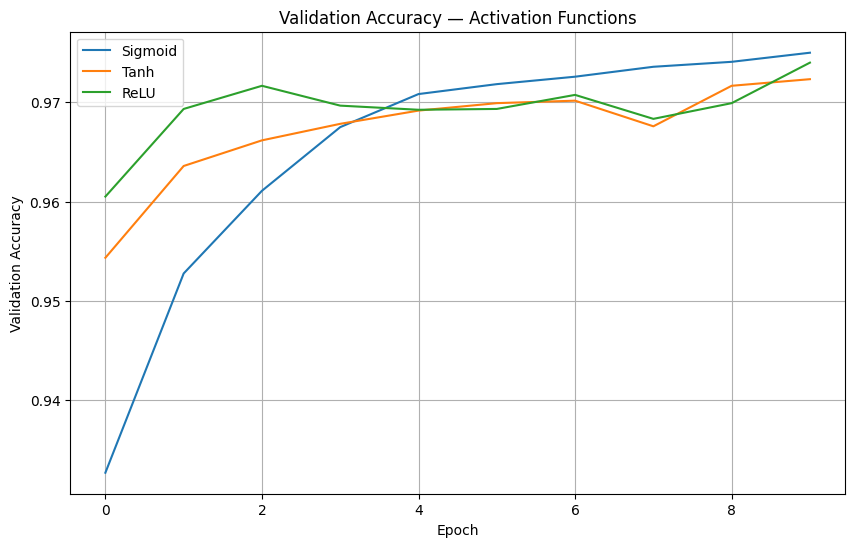

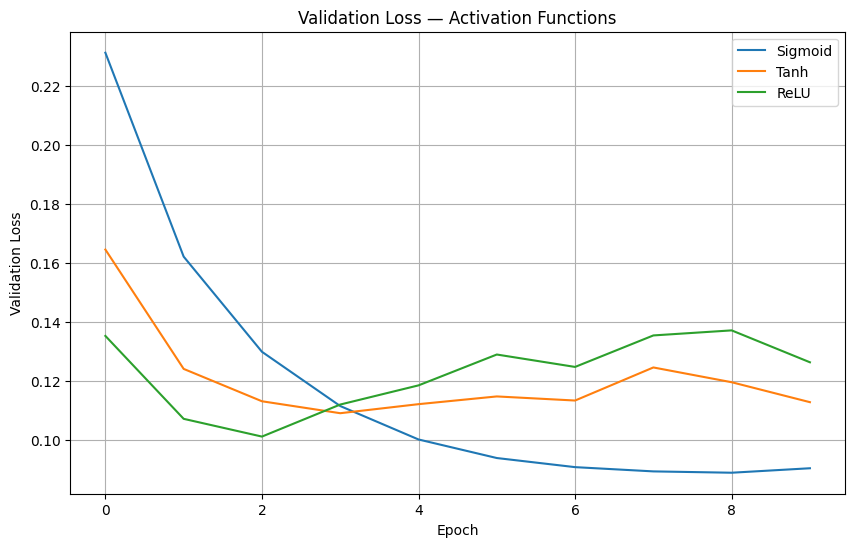

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')
plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy — Activation Functions')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid')
plt.plot(history_tanh.history['val_loss'], label='Tanh')
plt.plot(history_relu.history['val_loss'], label='ReLU')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss — Activation Functions')
plt.legend()
plt.grid()
plt.show()

### Task B Observation
Compare the actual results printed above. In general, ReLU is expected to train efficiently because it avoids saturation for positive inputs. Use the obtained accuracy and loss values from your run when writing the final observation.

## TASK C — Comparison of Optimization Algorithms
The same ANN architecture with ReLU activation is trained using SGD, Momentum, RMSProp and Adam.



**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  

In [6]:
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

def create_optimizer_model(optimizer):
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tf.random.set_seed(42)
sgd_model = create_optimizer_model(SGD(learning_rate=0.01))
history_sgd = sgd_model.fit(x_train, y_train, epochs=EPOCHS,
                            validation_split=VALIDATION_SPLIT, verbose=1)

tf.random.set_seed(42)
momentum_model = create_optimizer_model(SGD(learning_rate=0.01, momentum=0.9))
history_momentum = momentum_model.fit(x_train, y_train, epochs=EPOCHS,
                                     validation_split=VALIDATION_SPLIT, verbose=1)

tf.random.set_seed(42)
rmsprop_model = create_optimizer_model(RMSprop(learning_rate=0.001))
history_rmsprop = rmsprop_model.fit(x_train, y_train, epochs=EPOCHS,
                                    validation_split=VALIDATION_SPLIT, verbose=1)

tf.random.set_seed(42)
adam_model = create_optimizer_model(Adam(learning_rate=0.001))
history_adam = adam_model.fit(x_train, y_train, epochs=EPOCHS,
                              validation_split=VALIDATION_SPLIT, verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8163 - loss: 0.6915 - val_accuracy: 0.9055 - val_loss: 0.3362
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9093 - loss: 0.3202 - val_accuracy: 0.9213 - val_loss: 0.2720
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9239 - loss: 0.2675 - val_accuracy: 0.9308 - val_loss: 0.2372
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9341 - loss: 0.2323 - val_accuracy: 0.9376 - val_loss: 0.2110
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9415 - loss: 0.2057 - val_accuracy: 0.9436 - val_loss: 0.1910
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9475 - loss: 0.1846 - val_accuracy: 0.9486 - val_loss: 0.1751
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9529 - loss: 0.1673 - val_accuracy: 0.9520 - val_loss: 0.1620
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9566 - loss: 0.1527 -

In [7]:
optimizer_histories = {
    'SGD': history_sgd,
    'Momentum': history_momentum,
    'RMSProp': history_rmsprop,
    'Adam': history_adam
}

print('Optimizer | Train Accuracy | Val Accuracy | Train Loss | Val Loss')
for name, h in optimizer_histories.items():
    print(f'{name:9} | {h.history["accuracy"][-1]:.4f}         | '
          f'{h.history["val_accuracy"][-1]:.4f}       | '
          f'{h.history["loss"][-1]:.4f}     | {h.history["val_loss"][-1]:.4f}')

Optimizer | Train Accuracy | Val Accuracy | Train Loss | Val Loss
SGD       | 0.9632         | 0.9612       | 0.1297     | 0.1353
Momentum  | 0.9964         | 0.9756       | 0.0152     | 0.1006
RMSProp   | 0.9944         | 0.9717       | 0.0209     | 0.1613
Adam      | 0.9933         | 0.9737       | 0.0197     | 0.1270


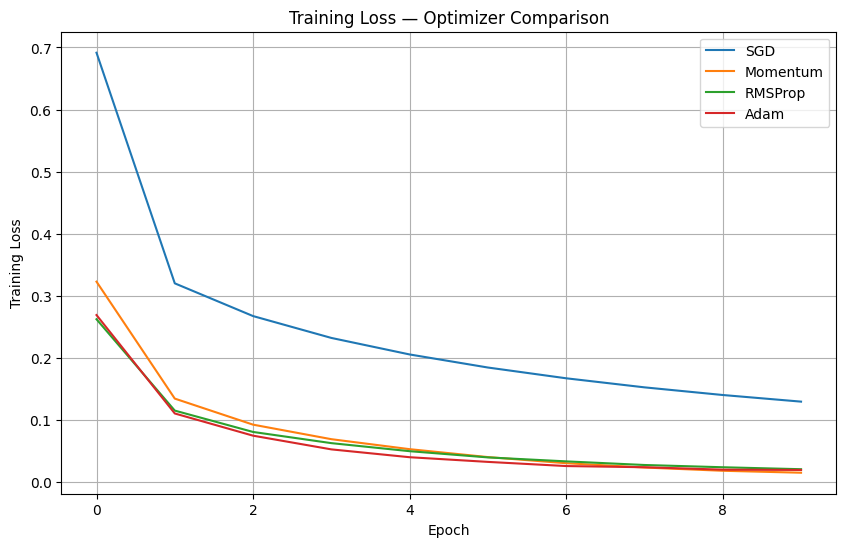

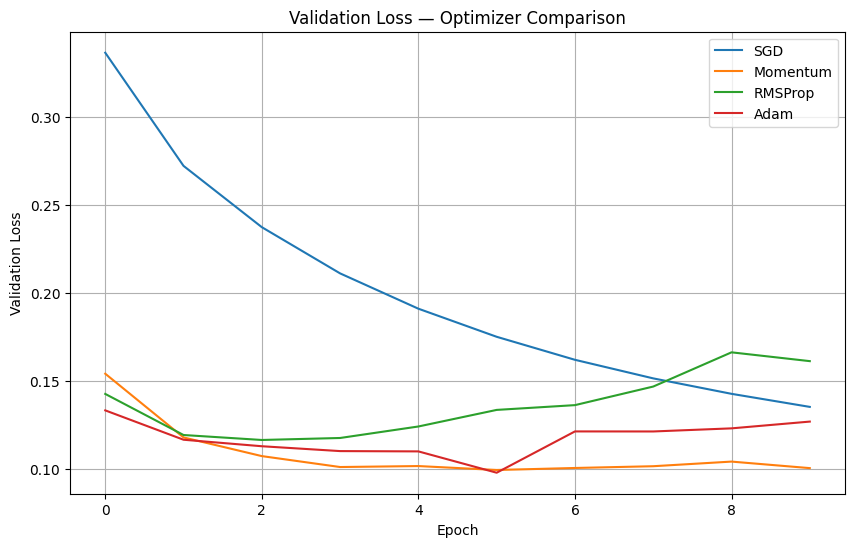

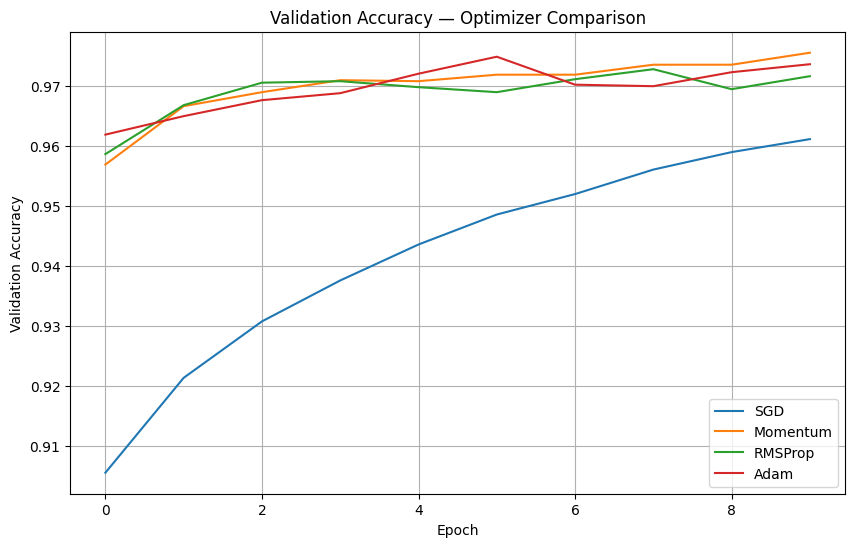

In [8]:
plt.figure(figsize=(10, 6))
for name, h in optimizer_histories.items():
    plt.plot(h.history['loss'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss — Optimizer Comparison')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
for name, h in optimizer_histories.items():
    plt.plot(h.history['val_loss'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss — Optimizer Comparison')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
for name, h in optimizer_histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy — Optimizer Comparison')
plt.legend()
plt.grid()
plt.show()

### Task C Observation
Use the printed results and graphs to identify which optimizer converges fastest, which has the lowest validation loss, and which gives the highest validation accuracy. Adam commonly provides fast convergence, but the conclusion for the lab should be based on the actual values from your run.

## TASK D — Deep Learning Experiment Management
Create a Colab notebook, mount Google Drive, save the notebook/models, and prepare the files for GitHub version control.



**Name:** Mohamed Aashik S  
**Roll No:** 24BAD072  

In [10]:
# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

base_folder = '/content/drive/MyDrive/EX2_Deep_Learning_24BAD072'
models_folder = os.path.join(base_folder, 'models')
results_folder = os.path.join(base_folder, 'results')

os.makedirs(models_folder, exist_ok=True)
os.makedirs(results_folder, exist_ok=True)

print('Experiment folder:', base_folder)
print('Models folder:', models_folder)
print('Results folder:', results_folder)

Experiment folder: /content/drive/MyDrive/EX2_Deep_Learning_24BAD072
Models folder: /content/drive/MyDrive/EX2_Deep_Learning_24BAD072/models
Results folder: /content/drive/MyDrive/EX2_Deep_Learning_24BAD072/results


In [12]:
# Save representative trained models to Google Drive
relu_model.save(os.path.join(models_folder, 'relu_activation_model.keras'))
adam_model.save(os.path.join(models_folder, 'adam_optimizer_model.keras'))
print('Models saved successfully.')

Models saved successfully.


## FINAL EXPERIMENT CONCLUSION
The experiment compares Sigmoid, Tanh and ReLU activation functions and evaluates SGD, Momentum, RMSProp and Adam optimization algorithms. The graphs and recorded metrics should be used to determine the best-performing activation function and optimizer for this particular run. ReLU and Adam are expected to provide efficient training in many ANN settings, but the final conclusion should be supported by the actual experimental results.